# Machine Learning Prediction of Antibiotic Resistance in Neisseria gonorrhoeae
**Name:**  ***M.EKRAMAH***
**Date:** 16 DEC 2025
**Reg#:** 04282213040
**Department:** National Centre for Bioinformatics (NCB) 

# 1. Introduction
## 1.1 Background
### Resistance of Bacteria in *Neisseria gonorrhoeae*
We focus on *Neisseria gonorrhoeae*, the bacteria causing gonorrhea, the second most common STI in Europe. Infection rates are rising (e.g., 26% increase in the UK from 2017-2018), and asymptomatic cases facilitate spread. Untreated infections can lead to severe complications like infertility.

Crucially, antimicrobial resistance (AMR) is increasing:
* **Historical:** Resistance rendered Ciprofloxacin ineffective.
* **Recent:** Azithromycin was removed from recommended dual-therapies due to rising resistance.
* **Current:** First reports of resistance to Ceftriaxone (the current standard) and Spectinomycin have emerged.

### Antibiotics of Interest
We model resistance for three specific antibiotics:

* **Azithromycin:** Used for respiratory, skin, and STI infections. Effective against typhoid and gonorrhea.
* **Ciprofloxacin:** Stops bacterial division. Used for urinary tract, skin, and lung infections.
* **Cefixime:** Effective for respiratory, urinary, and some sexually transmitted infections.

### Unitigs (Genomic Features)
Unitigs are stretches of DNA shared by a subset of bacterial strains, serving as an efficient representation of DNA variation.

* **Full Dataset:** 584,362 unitigs (too large for rapid training).
* **Our Dataset:** We use a filtered set of unitigs specifically associated with resistance.

## 1.2 Target Variables
The goal is binary classification: **Resistant (1)** vs. **Susceptible (0)**.

**Available Unitig Data:**
* Resistance to **Azithromycin** (`azm_sr`)
* Resistance to **Ciprofloxacin** (`cip_sr`)
* Resistance to **Cefixime** (`cfx_sr`)

**Unavailable Data:**
We lack unitig data for Ceftriaxone (`cro_sr`), Tetracycline (`tet_sr`), and Penicillin (`pen_sr`).

## 1.3 Aim
Our primary objective is to build machine learning models that distinguish whether *N. gonorrhoeae* is resistant to the three available antibiotics (Azithromycin, Ciprofloxacin, Cefixime) using genomic sequence data.

In [1]:
# --- 1. Installation  ---
!pip install catboost plotly xgboost scikit-learn seaborn matplotlib pandas numpy biopython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 35.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 18.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 29.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.7 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 51.5 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [60]:
!pip install dabl plotly


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.5/558.5 kB 10.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 98.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 115.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.2
    Uninstalling matplotlib-3.7.2:
      Successfully uninstalled matplotlib-3.7.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.17.0 requires matplotlib<

## 1.4 Imbalanced Data
The dataset contains extreme ratios between resistant and susceptible classes, which can lead to inaccurate models.

**Strategy:**
To address class bias, we will modify the feature matrix. We will employ upsampling techniques, such as **SMOTE (Synthetic Minority Over-sampling Technique)**, to create additional minority class samples and ensure the model learns to identify resistant cases effectively.

In [3]:

# --- 2. System & Data Handling ---
import os
import time
import warnings
import pandas as pd
import numpy as np
from Bio.Seq import Seq  # For DNA analysis

# --- 3. Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# --- 4. Machine Learning & Metrics ---
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    f1_score,
    precision_score,
    recall_score,
    classification_report, 
    roc_curve, 
    auc,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE, SMOTENC # Ensure these are imported for mod_unitigs

# --- 5. The ML Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Settings
sns.set(style='whitegrid')
warnings.filterwarnings("ignore")

print("✅ Environment set up successfully (Imports Consolidated).")



✅ Environment set up successfully.


In [4]:
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter

def dict_sum(dictlist):
  outdic = {}
  for d in dictlist:
    for k in d.keys():
      outdic[k] = 0
  for d in dictlist:
    for k in d.keys():
      outdic[k]+=d[k]
  return outdic

# Class for Sequence Operations 
class SQ: 
    
    def __init__ (self, seq=None, seq_type = "DNA"): 
        self.seq = seq.upper()
        self.seq_type = seq_type
          
    # class instance operations
    def __len__(self):
        return len(self.seq)
    def __getitem__(self, n):
        return self.seq[n]
    def __getslice__(self, i, j):
        return self.seq[i:j]
    def __str__(self):
        return self.seq
    
    # Frequency of Sybols 
    def freq(self,compare=None,show_id='perc',fheight=None,fwidth=None):
        
        if(compare is not None):
            if(self.seq_type != compare.seq_type):
                print('sequences are not of same type')
                return None
            
        c1 = dict(Counter(self.seq)) 
        if(compare is not None):
            c2 = dict(Counter(compare))  
            
        abc = list(self.abc())
        count = Counter(abc)
        abc_c = dict(Counter({x:0 for x in count}))
        
        c_all1 = dict_sum([c1,abc_c])
        if(compare is not None):
            c_all2 = dict_sum([c2,abc_c])    

        lst = []
        for i in c_all1.keys():
           if(self.seq_type == 'DNA' or self.seq_type == 'mRNA'):
               lst.append(dic_map('iupac_nucleotide',i))
           elif(self.seq_type == 'PROTEIN'):
               lst.append(dic_map('iupac_amino',i))
                
        if(compare is not None):
            lst2 = []
            for i in c_all2.keys():
               if(self.seq_type == 'DNA' or self.seq_type == 'mRNA'):
                   lst2.append(dic_map('iupac_nucleotide',i))
               elif(self.seq_type == 'PROTEIN'):
                   lst2.append(dic_map('iupac_amino',i))
          
        perc = [round(x / len(self.seq),3) for x in [*c_all1.values()]]
        if(show_id is 'perc'):
            show1 = lst; show2 = perc
        elif(show_id is 'count'):
            show1 = lst; show2 = [*c_all1.values()]
        fig = go.Figure(go.Bar(y=show1,x=show2,
                               marker_color='rgb(26, 118, 255)',
                               orientation='h',text=show2,
                               textposition='outside',name='SEQ1'))
        if(compare is not None):
            perc = [round(x / len(compare),3) for x in [*c_all2.values()]]
            if(show_id is 'perc'):
                show1 = lst2; show2 = perc
            elif(show_id is 'count'):
                show1 = lst2; show2 = [*c_all2.values()]
            fig.add_trace(go.Bar(y=show1,x=show2,marker_color='rgb(55, 83, 109)',
                                 orientation='h',text=show2,
                                 textposition='outside',name='SEQ2'))
        fig.update_layout(template='plotly_white',height=fheight,width=fwidth,
                         title=f'<b>{self.seq_type} SEQUENCE CONTENT</b>',
                         font=dict(family='sans-serif',size=12),
                         margin=dict(l=40, r=40, t=50, b=10))
        fig.show()

    # Return % GC Nucleotides
    def gc(self):
        if (self.seq_type == "DNA" or self.seq_type == "mRNA"):
            ii = 0
            for s in self.seq:
                if(s in "GCgc"):
                    ii += 1
            return round(ii / len(self.seq),4)
        else:
            return None
        
    # General Sequence Info
    def get_seq_biotype (self):
        return self.seq_type
    def info(self):
        print (f"SEQ: {self.seq}" +" "+ f"TYPE: {self.seq_type}")
        
    # Get ABC
    def abc(self):
        if(self.seq_type=="DNA"): 
          return "ACGT"
        elif(self.seq_type=="mRNA"):
          return "ACGU"
        elif (self.seq_type=="PROTEIN"): 
          return "ACDEFGHIKLMNPQRSTVWY"
        else: 
          return None
        
    # Check Validity
    def validate(self,verbose=False):
        alp = self.abc()
        res = True; i = 0
        while (res and i < len(self.seq)):
            if self.seq[i] not in alp: 
                res = False
            else: i += 1
        if(res):
            if(verbose):
                print(f'{self.seq_type} is valid')
            return res
        else:
            if(verbose):
                print(f'{self.seq_type} is invalid')
            return res
        
    # Transcription 
    def transcription(self):
        if (self.seq_type == "DNA"):
            return SQ(self.seq.replace("T","U"), "mRNA")
        else:
            return None
    
    # Reverse Compliment
    def reverse_comp(self):
        
        if (self.seq_type != "DNA"): 
            print('input not DNA')
            return None
    
        lst_seq = ['A','T','G','C']
        lst_comp = ['T','A','C','G']
            
        comp = ''
        for char in self.seq:
            ii=-1
            for c in lst_seq:
                ii+=1
                if(char == c ):
                    comp = lst_comp[ii] + comp
            
        return SQ(comp, "DNA")
        
    # Translate 
    @staticmethod
    def translate(seq,p0=0):
        seq_aa = ""
        for pos in range(p0,len(seq)-2,3):
            cod = seq[pos:pos+3]
            seq_aa += dic_map(map_id='codon',tid=cod)
        return seq_aa
    
    '''Get All Possible open reading frames (ORF)'''
    # store all possible collections of amino acid groups 
    # in all 6 frames
    def frames(self):
        res = []
        for i in range(0,3):
            res.append(self.translate(self.seq,i))
        rc = self.reverse_comp()
        for i in range(0,3):
            res.append(self.translate(rc,i)) 
        return res
    
    '''Computes all possible proteins in an amino acid sequence in reading frame '''
    # using the knowledge that it starts with M and ends with _, 
    # filter out rule breaking ORFs
    @staticmethod
    def all_proteins_RF(aa_seq):
        # aa_seq -> converted ORF
        current_prot = []
        proteins = []
        for aa in aa_seq:
            if(aa == "_"):
                if current_prot:
                    for p in current_prot:
                        proteins.append(p)
                    current_prot = []
            else:
                if(aa == "M"):
                    current_prot.append("")
                for i in range(len(current_prot)):
                    current_prot[i] += aa
        return proteins
    
    '''Computes all possible proteins for all ORF'''
    # and sort them based on size
    def ORF_protein(self, mins = 0):
        
        # order 
        def insert_prot_ord (prot, list_prots):
            i = 0
            while i < len(list_prots) and len(prot) < len(list_prots[i]):        
                i += 1
            list_prots.insert(i, prot)
        
        rfs = self.frames()  # get all ORF conversions
        res = []
        for rf in rfs:
            print(rf)
            prots = self.all_proteins_RF(rf) # return only protein cases
            # additionally sort based on protein size
            for p in prots: 
                if len(p) > mins: 
                    insert_prot_ord(p, res)
        return res
    
# Plot Correlation to Target Variable only
def corrMat(df,target='demand',figsize=(9,0.5),ret_id=False):
    
    corr_mat = df.corr().round(2);shape = corr_mat.shape[0]
    corr_mat = corr_mat.transpose()
    corr = corr_mat.loc[:, df.columns == target].transpose().copy()
    
    if(ret_id is False):
        f, ax = plt.subplots(figsize=figsize)
        sns.heatmap(corr,vmin=-0.3,vmax=0.3,center=0, 
                     cmap=cmap,square=False,lw=2,annot=True,cbar=False)
        plt.title(f'Feature Correlation to {target}')
    
    if(ret_id):
        return corr

# 2. The Dataset
## 2.1 Creating Case Data
### The `Get_Unitigs` Class
To prepare the data for our 5 machine learning models, we perform data wrangling to combine source files. We organize the data into a **case type format** comprising:
* **Feature Matrix ($X$):** Collected genomic unitigs.
* **Target Vector ($y$):** Binary resistance labels.

### Feature Matrix: Unitigs
The feature matrix consists of **unitigs**—stretches of bacterial DNA cut into **31-mer segments**. These serve as binary genomic markers:
* **1:** The unitig is present in the isolate's DNA.
* **0:** The unitig is absent.

### Merging Rtab & Metadata
* **Source:** Filtered unitig data is located in `.Rtab` files.
* **Process:** We read the `.Rtab` files and merge them with the associated metadata dataframe based on the `sample_id` index.
* **Implementation:** This merge is executed using the `.get_case()` method.

In [5]:
import pandas as pd
import numpy as np
import os

''' Align Metadata Target values w/ Unitig File & Compile Feature Matrix '''
class get_unitigs:
    
    def __init__(self,verbose=True):
        self.df = pd.read_csv('../input/gono-unitigs/metadata.csv', index_col=0) # metadata
        self.meta_names = self.df.columns 
        self.target_name = None
        self.verbose = verbose
    
    # Get Unitig Feature matrix & Target Vector
    def get_case(self,phenotype=None):
    
        self.target_name = phenotype
        _metadata = self.df
        if(self.verbose):
            print(f'Target Antibiotic: {self.target_name}')
            print(f'Metadata df: {_metadata.shape}')
        
        # remove those that don't contain target values
        _metadata = _metadata.dropna(subset=[phenotype])
        self.metadata = _metadata.copy()
        
        if(self.verbose):
            print(f'Metadata df after na() removal {_metadata.shape}')
        _metadata = _metadata[phenotype] # choose target variable 
        
        prefix = '../input/gono-unitigs/'
        suffix = '_gwas_filtered_unitigs.Rtab'
        
        if(self.verbose):
            print('\nCombining Metadata & Unitigs')
        
        # unitig feature matrix for phenotype
        tdf = pd.read_csv(prefix + phenotype + suffix, sep=" ", 
                          index_col=0, low_memory=False)
        # align column data w/ metadata df (pattern_id = sample_idd)
        tdf = tdf.T 
        # keep only common rows, ie. that have resistence measure]
        tdf = tdf[tdf.index.isin(_metadata.index)] 
        
        train = tdf
        target = _metadata[_metadata.index.isin(tdf.index)]

        self.X = pd.concat([train,target],axis=1)
        if(self.verbose):
            print(f'Unitig Matrix (+target): {self.X.shape}')

# 2.2 Case Preview - Ciprofloxacin
In this notebook, we analyze bacterial resistance across three distinct cases, beginning with **Ciprofloxacin**. We will load the remaining cases (Azithromycin, Cefixime) dynamically as required.

### Metadata Content
The metadata is stored in `.df` and indexed by `Sample_ID`. It contains phenotypic resistance labels (target variables) designated by `_sr` suffixes.

**Handling Missing Data:**
* The metadata contains missing entries (NaN).
* **Strategy:** We explicitly drop rows only where the specific target variable for the current case (e.g., `cip_sr`) is missing, ensuring we maximize usable data.

### Feature Matrix Construction
The feature matrix is generated from the specific `.Rtab` file corresponding to the antibiotic case.

* **Index:** `Sample_ID` (links features to metadata).
* **Columns:** Unitigs (identified by `pattern_id`).
* **Values:** Binary indicators (1/0) representing the presence or absence of the specific DNA sequence in the isolate.

In [6]:
# load meta data & look at the first 5 samples
case_cip = get_unitigs()
display(case_cip.df.T.iloc[:,:5])

Sample_ID,ERR1549286,ERR1549290,ERR1549291,ERR1549287,ERR1549288
Year,2015.0,2015.0,2015.0,2015.0,2015.0
Country,UK,UK,UK,UK,UK
Continent,Europe,Europe,Europe,Europe,Europe
Beta.lactamase,NaN,NaN,NaN,NaN,NaN
Azithromycin,>256,>256,>256,>256,>256
Ciprofloxacin,NaN,NaN,NaN,NaN,NaN
Ceftriaxone,0.016,0.004,0.006,0.006,0.008
Cefixime,NaN,NaN,NaN,NaN,NaN
Tetracycline,NaN,NaN,NaN,NaN,NaN
Penicillin,NaN,NaN,NaN,NaN,NaN


In [7]:
case_cip.get_case(phenotype='cip_sr')
case_cip.X.iloc[:,:2].head()

Target Antibiotic: cip_sr
Metadata df: (3786, 30)
Metadata df after na() removal (3088, 30)

Combining Metadata & Unitigs
Unitig Matrix (+target): (3088, 8874)


,ACGTTTATGCCGTTATCGATCCGATAGCCGGT,CATCTGCACCCTGTCGGCACTCGCCGCCTGAACCACCCCGTCCGGACAAGG
SRR1661154,0,0
SRR1661156,0,0
SRR1661157,0,0
SRR1661158,0,0
SRR1661159,0,0


TARGET VARIABLE

The target vector, is also stored in .X, and represents the resistance property of the sample

The Sample_ID is either 1.0 (resistant) or 0.0 (non-resistant) to a particular antibiotic in question.

In [8]:
target = case_cip.X[case_cip.target_name]
print(target[:5])

SRR1661154    0.0
SRR1661156    1.0
SRR1661157    0.0
SRR1661158    0.0
SRR1661159    0.0
Name: cip_sr, dtype: float64


### Target Variable
The target vector is aligned with our feature matrix ($X$) and represents the phenotypic resistance status of each bacterial isolate.

* **Values:**
    * **1.0:** The sample is **Resistant** to the antibiotic.
    * **0.0:** The sample is **Susceptible** (Non-Resistant).

In [9]:
''' Ciprofloxacin '''

case = get_unitigs()
case.get_case('cip_sr')
print(case.X[case.target_name].value_counts())

Target Antibiotic: cip_sr
Metadata df: (3786, 30)
Metadata df after na() removal (3088, 30)

Combining Metadata & Unitigs
Unitig Matrix (+target): (3088, 8874)
cip_sr
0.0    1660
1.0    1428
Name: count, dtype: int64


In [10]:
''' Azithromycin '''

case = get_unitigs()
case.get_case('azm_sr')
print(case.X[case.target_name].value_counts())

Target Antibiotic: azm_sr
Metadata df: (3786, 30)
Metadata df after na() removal (3478, 30)

Combining Metadata & Unitigs
Unitig Matrix (+target): (3478, 516)
azm_sr
0.0    3031
1.0     447
Name: count, dtype: int64


In [11]:
''' Cefixime '''

case = get_unitigs()
case.get_case('cfx_sr')
print(case.X[case.target_name].value_counts())

Target Antibiotic: cfx_sr
Metadata df: (3786, 30)
Metadata df after na() removal (3401, 30)

Combining Metadata & Unitigs
Unitig Matrix (+target): (3401, 385)
cfx_sr
0.0    3396
1.0       5
Name: count, dtype: int64


# 3. Feature Matrix Modification
## 3.1 Modifying Case Data
### The Problem: Not Enough Resistant Samples
In our data analysis, we noticed a major issue: some antibiotics (especially **Cefixime**) have very few positive "Resistant" samples compared to "Non-Resistant" ones.

**Why is this a problem?**
* If we don't have enough examples of resistance, the model cannot learn what resistance looks like.
* It makes **Cross-Validation** unreliable because some test folds might end up with zero resistant cases.
* **Note:** Azithromycin and Ciprofloxacin have enough data, so they don't suffer as much from this specific problem.

### How We Fix It
To ensure our 5 models (Logistic Regression, RF, SVM, XGBoost, CatBoost) can learn effectively, we will try two different approaches to balance the data:

1.  **Downsampling (`.split_case`):**
    * We randomly remove some of the "Non-Resistant" (dominant) samples until the classes are more balanced.
    * *Risk:* We lose real data.

2.  **Upsampling (`SMOTE`):**
    * We use **SMOTE** (Synthetic Minority Over-sampling Technique).
    * This algorithm looks at the existing resistant samples and creates new, synthetic examples that look similar.
    * *Benefit:* We keep all our data and give the model more examples to learn from.

In [13]:
''' Feature Matrix Upsampling Modification (+Target) '''
# Model based approach to upsample minor class in target variable

class mod_unitigs():
    
    def __init__(self,unitigs):
        self.X = unitigs.X # input data class
        self.target_name = unitigs.target_name
        self.verbose = True

    ''' Downsampling Class 0 using .sample & recompile '''
    # If there's too much of the dominant class, just downsample
    
    def split_case(self,frac_id=0.5):
        
        X = self.train
        y = pd.Series(self.target,name=self.target_name)
        XX = pd.concat([X,y],axis=1)
        
        lst_temp = dict(tuple(XX.groupby(self.target_name))) # divide classes
        ratio = lst_temp[0].shape[0]/lst_temp[1].shape[0] # get class ratio
        
        # Sample approach for downsizing majority class
        X_red = lst_temp[0].sample(frac=frac_id)
        X_all = pd.concat([X_red,lst_temp[1]],axis=0)
        
        if(self.verbose):
            print(f'Class 0 : {lst_temp[0].shape}')
            print(f'Class 1 : {lst_temp[1].shape}')
            print(f'Class Ratio: {round(ratio,4)}')
            print(f'Reduced Training Matrix: {X_all.shape}')
        
        # Redefine .train, .target
        self.target = X_all[self.target_name].copy()
        X_all.drop(self.target_name, inplace=True, axis=1)
        self.train = X_all
        
    ''' SMOTE UPSAMPLING '''
    # For unbalanced problems, synthetically/model new data
        
    def smote(self,smote_id = 'smotenc',
                   smote_strat=0.5,
                   k_neighbours=5):
        
        self.smote_id = smote_id
        self.smote_strat = smote_strat
        self.smote_nbr = k_neighbours
        
        y = self.X[self.target_name].copy()
        X = self.X.drop([self.target_name],axis=1).copy()
    
        # smote for contin, smotenc for category
        if(self.smote_id is 'smote'):
            model_id = SMOTE(sampling_strategy=self.smote_strat,
                             k_neighbors=self.smote_nbr)
        elif(self.smote_id is 'smotenc'):
            model_id = SMOTENC(sampling_strategy=self.smote_strat,
                               k_neighbors=self.smote_nbr,
                               categorical_features=[0,1])
        
        X_mod, y_mod = model_id.fit_resample(X,y)
        self.X = pd.concat([X_mod,y_mod],axis=1)
        
        if(self.verbose):
            print(f'\nSMOTE Upsampling: {self.X.shape}')
            print(f'Target Value Counts: \n{pd.Series(y_mod).value_counts()}')
        self.X = pd.concat([X_mod,y_mod],axis=1)

# 3. Exploratory Data Analysis
## 3.1 Parallel Categories
### Exploring the Metadata
Before diving into the genomic models, we explore the metadata to understand the characteristics of our 3,478 samples. This helps us see how factors like **time**, **location**, and **resistance types** relate to each other.

### Key Observations from the Data
By visualizing the connections between categories, we observed the following:

* **Beta-lactamase:** This enzyme generally doesn't show a clear pattern with resistance, *except* for Penicillin. If a bacteria has the "Resistant" (R) type for Beta-lactamase, Penicillin is almost exclusively ineffective.
* **Sensitivity:** The majority of bacterial samples in our dataset are of the "Sensitive" (S) type.
* **Time Trend:** If we look at the year of collection, resistance to these antibiotics tends to be **rising over time**.

In [62]:
# Force install a compatible version pair
!pip install scikit-learn==1.2.2 dabl --force-reinstall

  Using cached dabl-0.3.2-py3-none-any.whl.metadata (5.2 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of dabl to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.9 MB/s eta 0:00:00
  Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 89.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.0/567.0 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 23.8 MB/s eta 0:00:00
Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
   ━━━━━━━━━━━━━━━━

--- Overview for Cefixime (Target: cfx_sr) ---


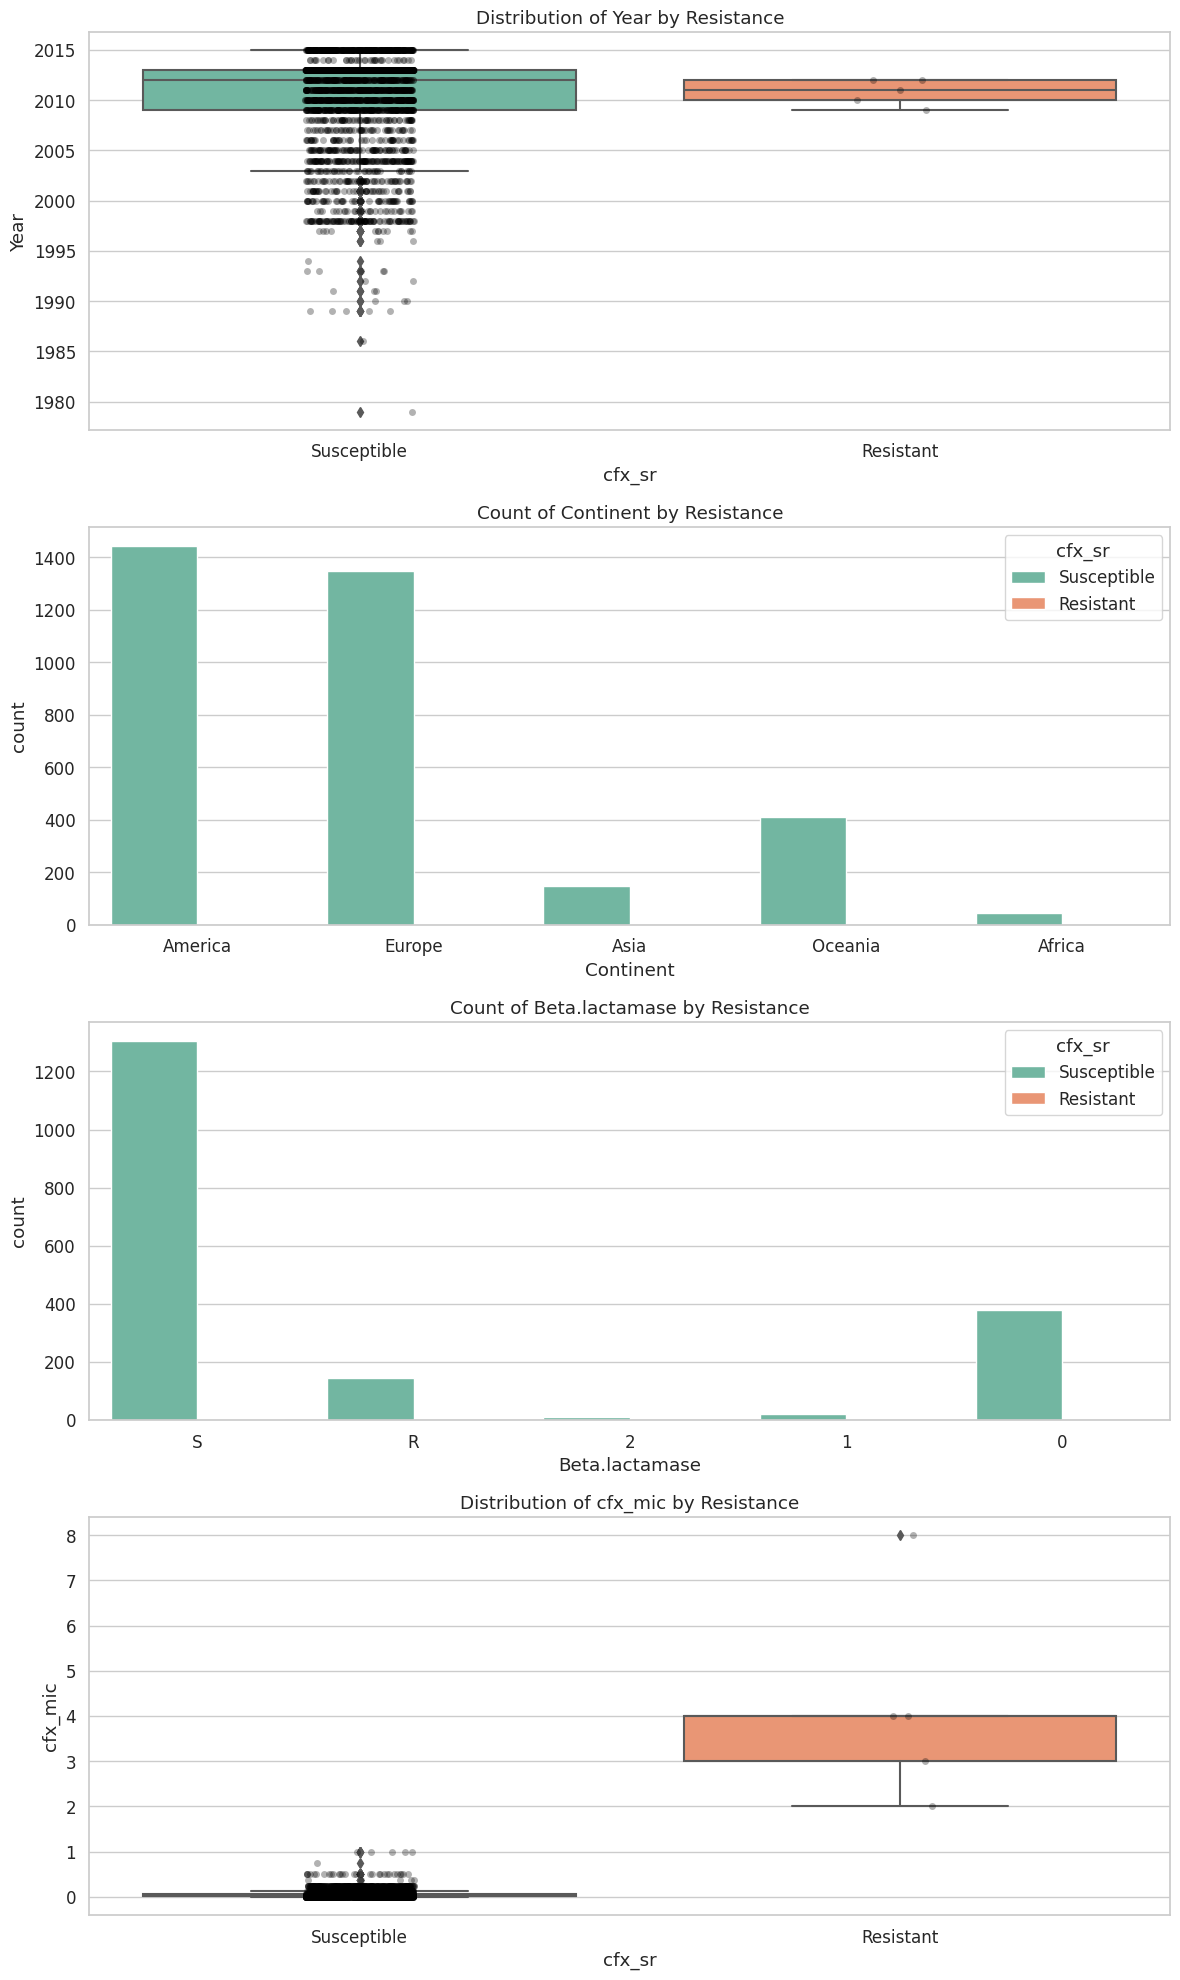

--- Overview for Ciprofloxacin (Target: cip_sr) ---


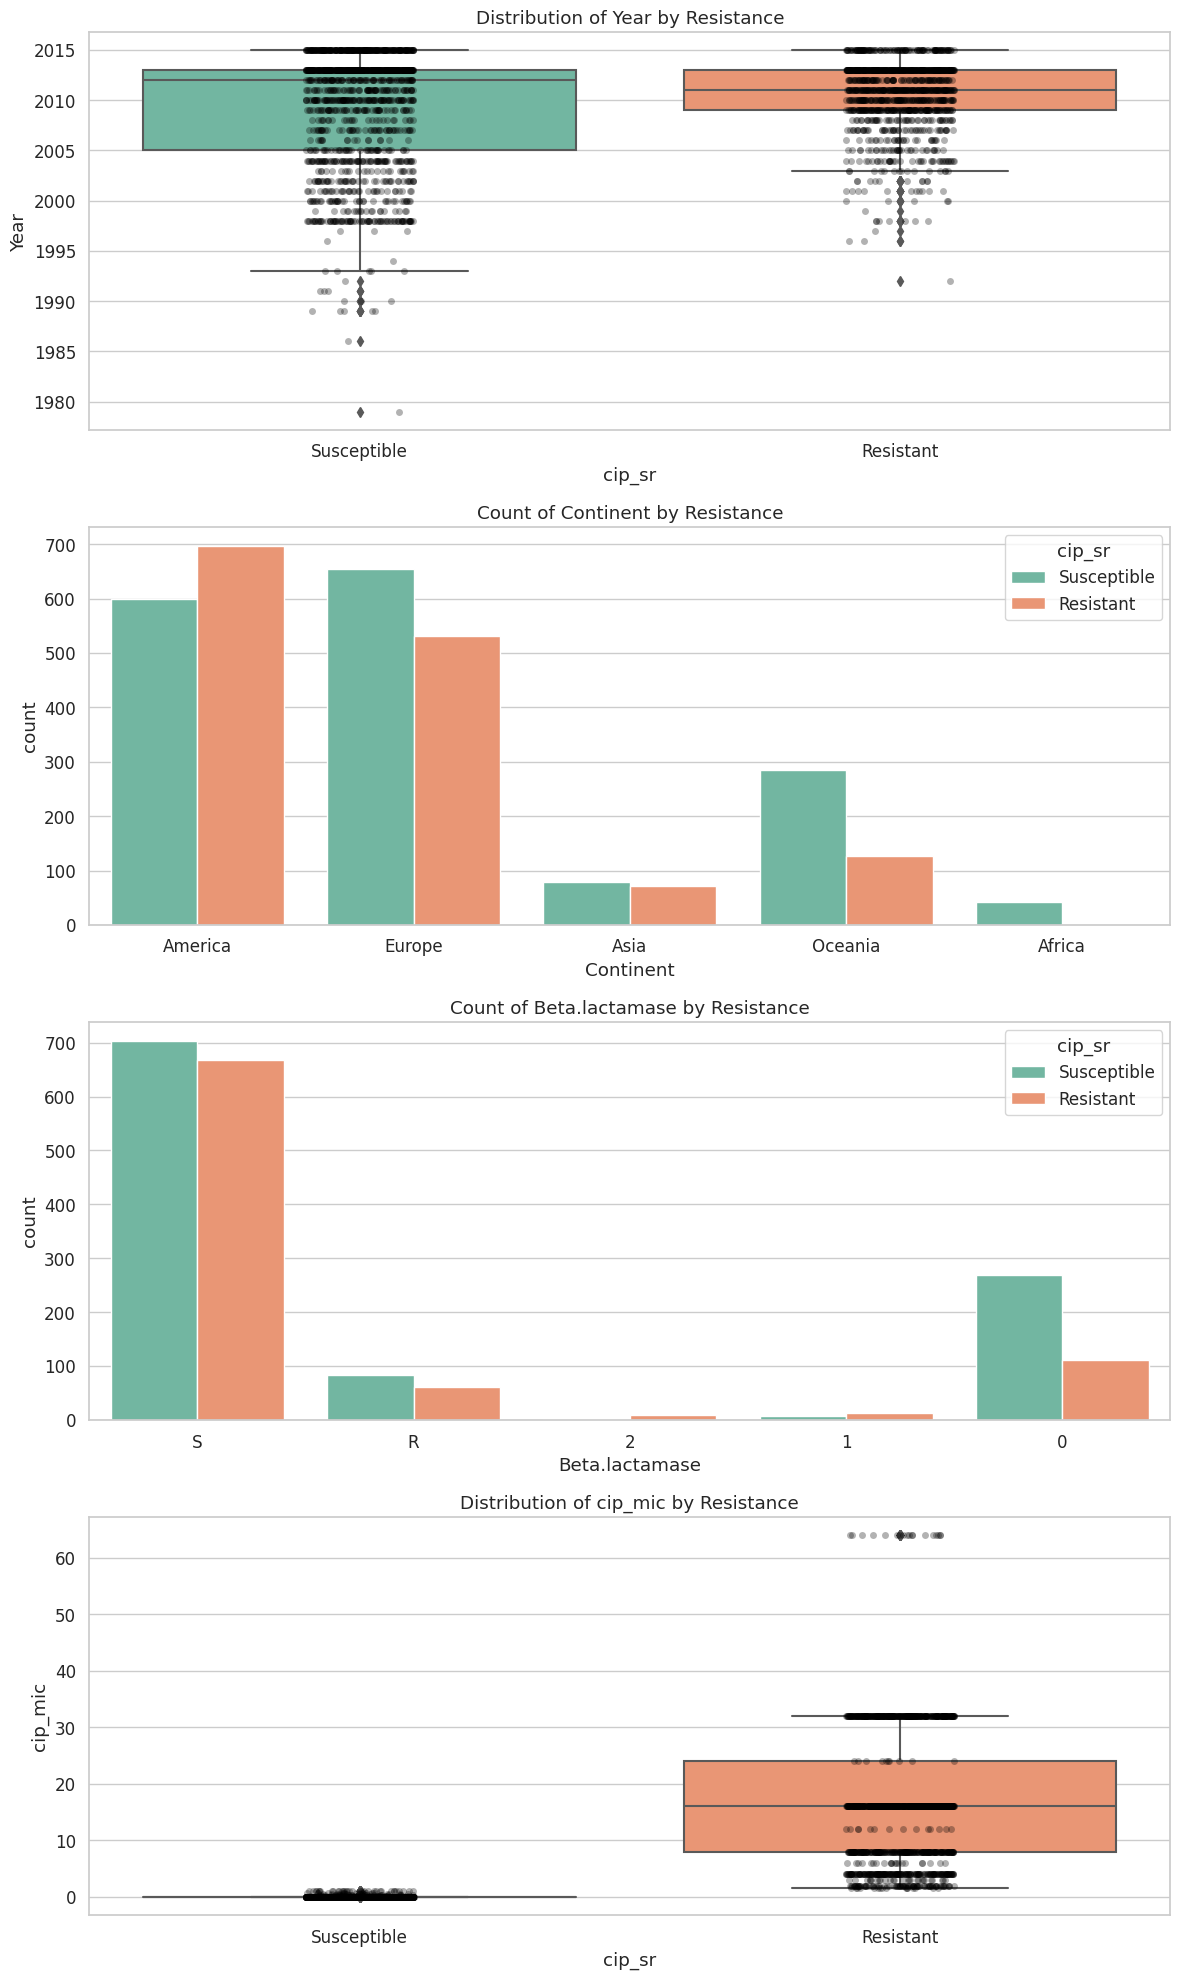

--- Overview for Azithromycin (Target: azm_sr) ---


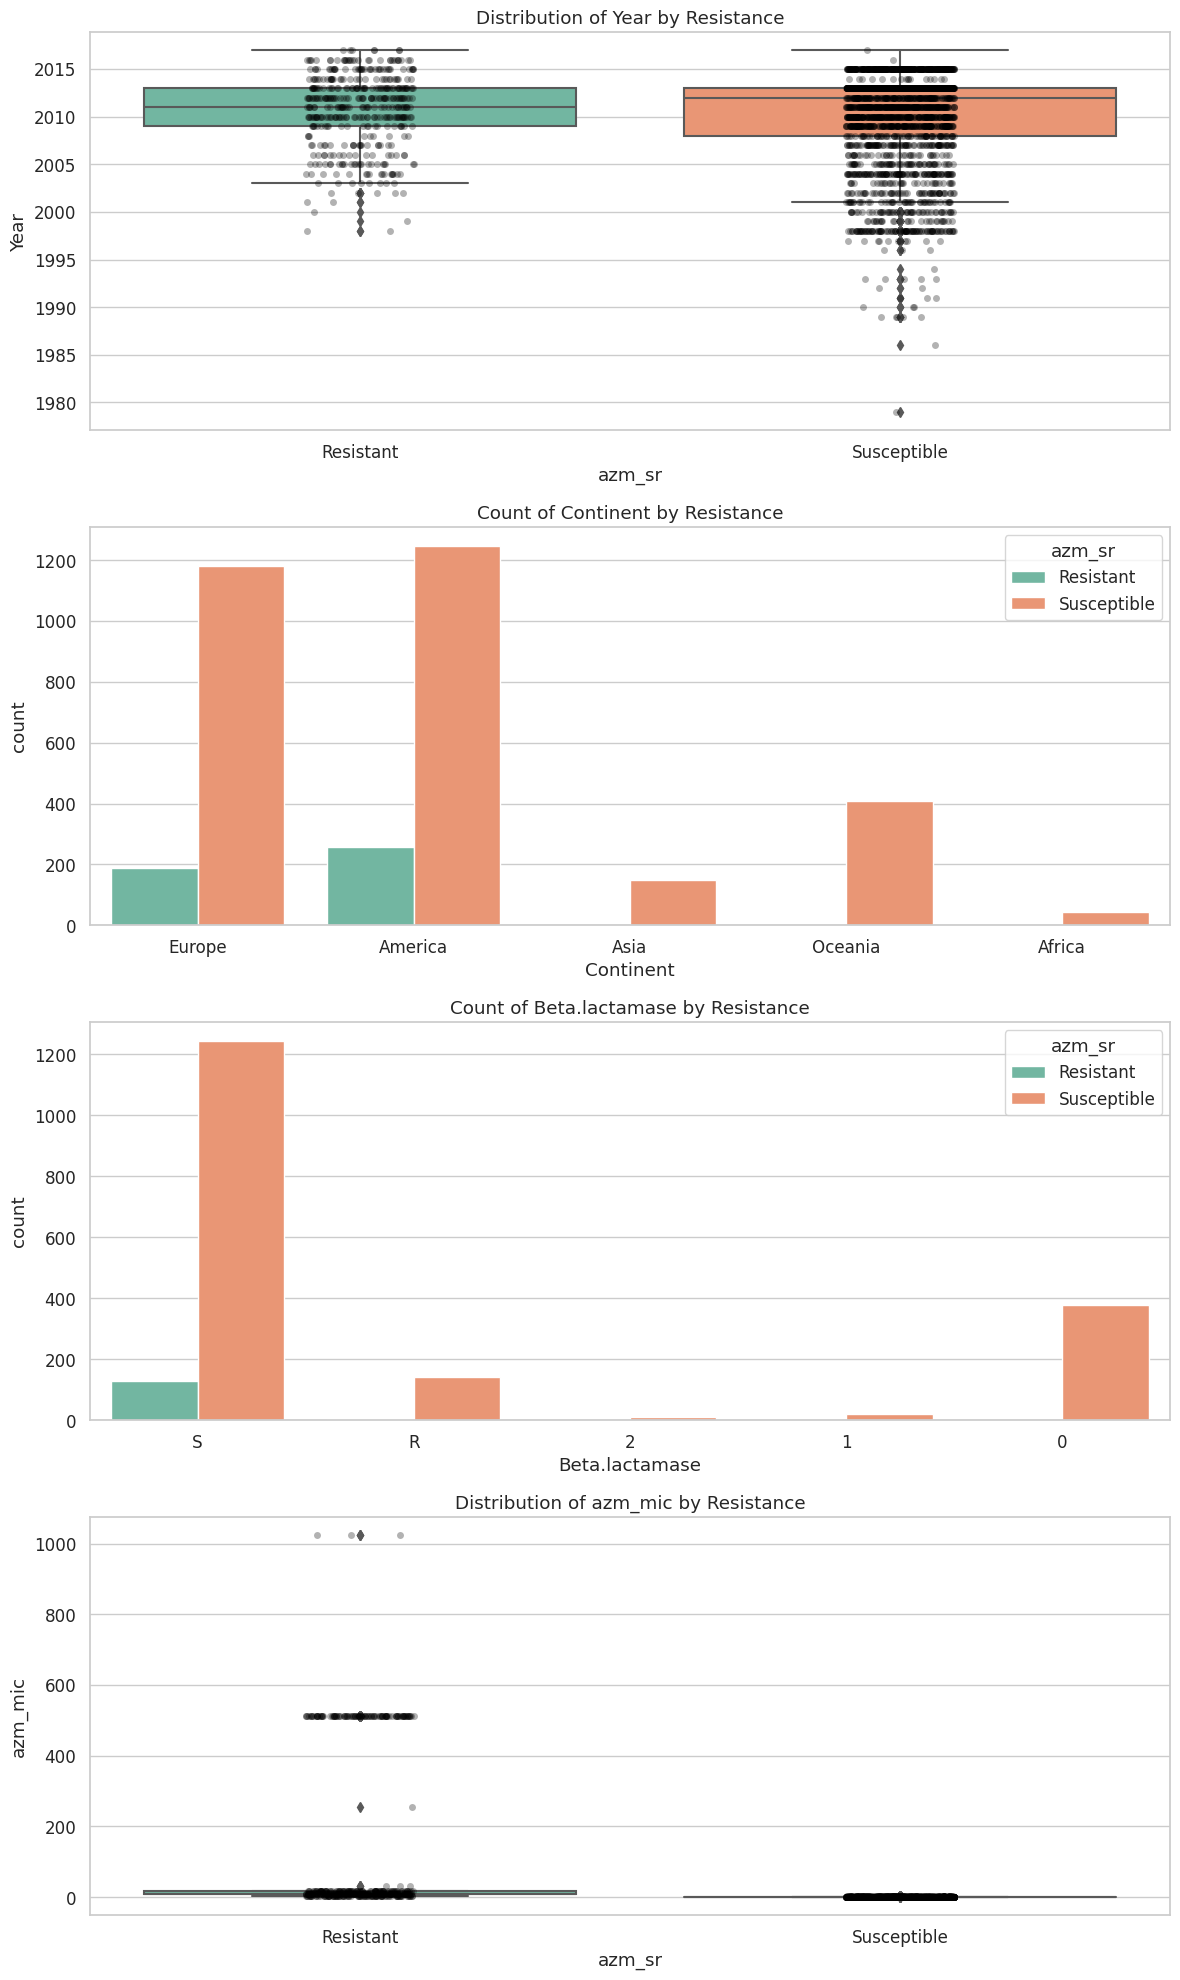

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

# --- 1. Define the Custom EDA Function (Replaces Dabl) ---
def plot_antibiotic_overview(df, target_col, antibiotic_name):

    print(f"--- Overview for {antibiotic_name} (Target: {target_col}) ---")
    
    # Clean data (remove unknown resistance)
    plot_df = df.dropna(subset=[target_col]).copy()
    
    # Convert Target to String for clearer coloring (0='Susceptible', 1='Resistant')
    plot_df[target_col] = plot_df[target_col].replace({0.0: 'Susceptible', 1.0: 'Resistant', 0: 'Susceptible', 1: 'Resistant'})
    
    # Identify columns to plot (excluding the target itself)
    cols_to_plot = [c for c in df.columns if c != target_col]
    
    # Setup the grid
    num_plots = len(cols_to_plot)
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 5 * num_plots))
    if num_plots == 1: axes = [axes] # Handle single plot case
    
    for i, col in enumerate(cols_to_plot):
        ax = axes[i]
        
        # Check if numerical (like MIC values)
        if pd.api.types.is_numeric_dtype(plot_df[col]) and plot_df[col].nunique() > 10:
            sns.boxplot(data=plot_df, x=target_col, y=col, ax=ax, palette="Set2")
            sns.stripplot(data=plot_df, x=target_col, y=col, ax=ax, color='black', alpha=0.3, jitter=True)
            ax.set_title(f"Distribution of {col} by Resistance")
        
        # Otherwise treat as Categorical (Year, Country, Genotype)
        else:
            # For high cardinality (lots of countries), just show top 10
            if plot_df[col].nunique() > 15:
                top_10 = plot_df[col].value_counts().index[:15]
                temp_data = plot_df[plot_df[col].isin(top_10)]
                sns.countplot(data=temp_data, y=col, hue=target_col, ax=ax, palette="Set2", order=top_10)
                ax.set_title(f"Count of {col} (Top 15) by Resistance")
            else:
                sns.countplot(data=plot_df, x=col, hue=target_col, ax=ax, palette="Set2")
                ax.set_title(f"Count of {col} by Resistance")
                
    plt.tight_layout()
    plt.show()

# --- 2. Load Data ---
# Instantiate your existing loader
loader = get_unitigs(verbose=False) 
full_df = loader.df

# --- 3. Define Analysis Targets ---
# Structure: [Year, Continent, Genotype, MIC, DrugName, Target]
eda_configs = [
    ('Cefixime', 'cfx_sr', ['Year', 'Continent', 'Beta.lactamase', 'cfx_mic', 'cfx_sr']),
    ('Ciprofloxacin', 'cip_sr', ['Year', 'Continent', 'Beta.lactamase', 'cip_mic', 'cip_sr']),
    ('Azithromycin', 'azm_sr', ['Year', 'Continent', 'Beta.lactamase', 'azm_mic', 'azm_sr'])
]

# --- 4. Generate Plots ---
for name, target, cols in eda_configs:
    # Subset dataframe
    subset_df = full_df[cols]
    plot_antibiotic_overview(subset_df, target, name)

In [68]:
import plotly.express as px
import plotly.io as pio

# Set the default renderer to 'iframe' or 'notebook' 
# 'iframe' is best for ensuring it stays visible when exported to HTML
pio.renderers.default = "iframe"

# List of binary targets to visualize
targets = ['cip_sr', 'cfx_sr', 'azm_sr']

# Load data again to be safe
loader = get_unitigs(verbose=False)
df_tree = loader.df.copy()

# Ensure categorical columns are strings for better plotting
for col in ['Year', 'Continent', 'Beta.lactamase']:
    df_tree[col] = df_tree[col].astype(str)

for target in targets:
    # Filter for rows where the antibiotic data exists
    temp_df = df_tree.dropna(subset=[target])
    
    # Create the count column
    temp_df['count'] = 1 
    
    print(f"Generating Tree Map for: {target}")
    
    fig = px.treemap(
        temp_df, 
        path=['Year', 'Continent', 'Beta.lactamase'], 
        values='count', 
        color=target, 
        color_continuous_scale='RdBu_r', 
        title=f'Hierarchy of {target}: Size=Count, Color=Resistance Rate',
        height=600
    )
    
    # FIX: Explicitly rendering as an iframe ensures it appears in downloaded HTML
    fig.show(renderer="iframe")
    
    # OPTIONAL: Save as a standalone HTML file just in case
    # This creates a file you can open in Chrome/Edge manually if the notebook fails
    filename = f"treemap_{target}.html"
    fig.write_html(filename)
    print(f"Saved interactive plot to {filename}")

Generating Tree Map for: cip_sr


Saved interactive plot to treemap_cip_sr.html
Generating Tree Map for: cfx_sr


Saved interactive plot to treemap_cfx_sr.html
Generating Tree Map for: azm_sr


Saved interactive plot to treemap_azm_sr.html


In [66]:
lst_azm = ['Year','Continent','Beta.lactamase','azm_mic','Azithromycin','azm_sr']
lst_cip = ['Year','Continent','Beta.lactamase','cip_mic','Ciprofloxacin','cip_sr']
lst_cfx = ['Year','Continent','Beta.lactamase','cfx_mic','Cefixime','cfx_sr']
lst_antibio = [lst_azm,lst_cip,lst_cfx]

import plotly.express as px

def plot_pp(lst):
    # 1. Prepare Data
    tdf = get_unitigs().df[lst].copy()
    tdf.dropna(inplace=True)
    tdf.sort_values(by=lst[-3], inplace=True, ascending=False)
    tdf['Year'] = tdf['Year'].astype(str)

    # 2. Create Plot
    # We set 'color' to the last column (Resistance Status) for visibility
    fig = px.parallel_categories(
        tdf, 
        color=lst[-1],  
        color_continuous_scale=px.colors.sequential.Inferno
    )

    # 3. Style Updates
    fig.update_traces(patch={"line": {'shape': 'hspline'}}) 
    
    fig.update_layout(title=f'Bacteria Resistance to {lst[-2]}')
    fig.update_layout(margin=dict(t=60, b=10), height=400)
    fig.show()



In [67]:
# Run the loop
for i in lst_antibio:
    plot_pp(i)

### Which Antibiotics Work Best?
The data reveals clear differences in how well the treatments work:

1.  **Cefixime (Most Effective):** This is currently the most effective treatment among the three, with very few resistant cases found in the dataset.
2.  **Ciprofloxacin (Least Effective):** This antibiotic has lost much of its effectiveness, with many bacterial samples showing resistance to it.

# 3.3 Country Based Bacteria Resistance
## Geographic Variation in Treatments
Where the bacteria comes from matters. Although our dataset has more samples from some countries than others, we can still see clear patterns showing that antibiotic resistance varies by location.

In [19]:
# For the purposes of plotting; require standard codes for plotly chloropeth
country_map = {'UK':'GBR','Canada':'CAN','France':'FRA','Spain':'SPA','Austria':'AUT',
               'Italy':'ITA','Slovakia':'SVK','Norway':'NWY','Slovenia':'SVN',
               'Hungary':'HUN','The Netherlands':'NED','Belgium':'BEL','Greece':'GRC',
               'Sweden':'SWE','Denmark':'DNK','Germany':'GER','Latvia':'LAT',
               'Iceland':'ICL','Cyprus':'CYP','Malta':'MLT','Portugal':'PRT',
               'Brasil':'BRA','Chile':'CHL','Ecuador':'ECU','USA':'USA','Australia':'AUS',
               'Caribbean':'XXX','Cuba':'CUB','Poland':'POL','Romania':'ROU',
               'Russia':'RUS','Turkey':'TUR','Jamaica':'JAM','Lithuania':'LTU',
               'Scotland':'SCO','Argentina':'ARG','Thailand':'THA','Japan':'JPN',
               'New_Zealand':'NZL','India':'IND','China':'CHN','Indonesia':'IDN',
               'Philippines':'PHL','Vietnam':'VNM','Pakistan':'PAK','Bhutan':'BTN',
               'Estonia':'EST','Belarus':'BLR','Armenia':'ARM','Bulgaria':'BUL',
               'Finland':'FIN','HongKong':'HKG','Malaysia':'MYS','Gambia':'GMB',
               'South_Africa':'ZAF','Tanzania':'TZA','CaboVerde':'CPV','Marocko':'MAR',
               'Uganda':'UGA','Angola':'AGO','Guinea':'GIN','GuineaBissau':
               'GNB','Saudi_Arabia':'SAU','Ivory_Coast':'CIV','Ireland':'IRL'}

In [20]:
lst_azm = ['Year','Country','Continent','Beta.lactamase','azm_mic','Azithromycin','azm_sr']
lst_cip = ['Year','Country','Continent','Beta.lactamase','cip_mic','Ciprofloxacin','cip_sr']
lst_cfx = ['Year','Country','Continent','Beta.lactamase','cfx_mic','Cefixime','cfx_sr']
lst_antibio = [lst_azm,lst_cip,lst_cfx]

def plot_geomean(lst):
    global country_map

    tdf = get_unitigs().df[lst].copy() # Added .copy() to prevent SettingWithCopy warnings
    tdf.dropna(inplace=True)
    tdf.sort_values(by=lst[-3], inplace=True, ascending=False)
    
    # This conversion caused the error because 'Year' became a string
    tdf['Year'] = tdf['Year'].astype(str) 
    
    tdf['Country'] = tdf['Country'].map(country_map)
    
    # FIXED: Added numeric_only=True to ignore 'Year' and other string columns
    tdf2 = tdf.groupby(['Country']).mean(numeric_only=True)

    fig = go.Figure(data=go.Choropleth(
        locations = tdf2.index,
        z = tdf2[lst[-1]],
        colorscale = 'magenta',
        autocolorscale=False,
        reversescale=False,
        marker_line_color='black',
        marker_line_width=0.5,
        colorbar_title = f'{lst[-1]}'))

    fig.update_layout(title=f'Bacteria Resistance to {lst[-2]}',
                      geo=dict(showframe=False, showcoastlines=False,
                               projection_type='equirectangular'))
    fig.update_layout(margin=dict(t=60, b=10), height=400)
    fig.show()

In [21]:
# Plot Choropleth Map
for i in lst_antibio:
    plot_geomean(i)

### Which Countries Have the Highest Resistance?
The data highlights specific regions where treatments are failing:

1.  **Azithromycin:** Resistance is rare but present. The **US, Sweden, and China** are the only locations in our dataset showing unsuccessful treatment cases.
2.  **Ciprofloxacin:** This drug is struggling globally. It is particularly ineffective in **Chile, Finland, Vietnam, and China**.
3.  **Cefixime:** This remains a strong treatment choice worldwide. **France** is the only notable exception where we see some resistance.

# 3.4 MIC Values of All Samples
## What is MIC?
**MIC (Minimum Inhibitory Concentration)** measures the lowest concentration of an antibiotic required to stop bacterial growth.

* **Low MIC:** The bacteria are weak against the drug (Sensitive).
* **High MIC:** The bacteria can tolerate large amounts of the drug (Resistant).

In [24]:
def get_mic():
    
    lst_cases = ['azm_mic','cip_mic','cfx_mic']
    rtabs = ['azm_sr','cip_sr','cfx_sr']
    lst_temp = []
    
    ii=-1
    for case in lst_cases:
        
        ii+=1
        case_id = get_unitigs(verbose=False)
        case_id.get_case(rtabs[ii])
        
        X_all = pd.concat([case_id.X,case_id.metadata],axis=1)
        
        new_df = X_all[case].value_counts().rename_axis(case).reset_index(name='counts')
        new_df = new_df.rename(columns={new_df.columns[0]: 'mic'})
        new_df['case'] = case                
        lst_temp.append(new_df)
        
    X_counts = pd.concat([lst_temp[0],lst_temp[1],lst_temp[2]],axis=0)
    X_counts.sort_values(by='mic',inplace=True,ascending=True)
    X_counts['mic'] = X_counts['mic'].astype(str)

    fig = px.bar(X_counts, x='mic',y='counts',color='case')
    fig.update_layout(template='plotly_white',height=300)
    fig.show()

### Visualizing Resistance Trends
The graph highlights a clear relationship between MIC values and resistance:

1.  **Cefixime:** Most samples show very low MIC values. This confirms that only small quantities are needed to stop the bacteria, making it a highly effective treatment.
2.  **Azithromycin & Ciprofloxacin:** These antibiotics show much higher MIC values. This indicates that the bacteria are tolerating higher doses, hinting that resistance is common and larger quantities are required for treatment.

In [25]:
get_mic()

# 3.5 Unitig Analysis
## Unique Values of All Unitigs
Our feature matrix ($X$) is built entirely from binary data.

* **What does this mean?** Every single column (representing a Unitig) contains only two possible values:
    * **1 (Present):** The DNA segment was found in the bacterial sample.
    * **0 (Not Present):** The DNA segment was not found.

This binary structure makes the data clean and ready for machine learning algorithms without needing complex scaling.

In [26]:
column_values = case.X[case.target_name].values.ravel()
print(pd.unique(column_values))

[0. 1.]


GROUPED UNITIGS

Some columns also contain multiple unitigs which we can note below as well, perhaps indicating that all grouped unitigs must be present in a given Sample_ID.

In [27]:
case_unitigs = case.X.columns.tolist()

ii=-1
for i in case_unitigs:
    if(',' in i):
        ii+=1;print(f'{ii} | {i}')

0 | TTCAACTCTTCATAAGCCAAAGTCTGAATCCTCTGATC,AACAGCTCCTTAACCTGCGTGCGGTACAGGCGTTCGGCGCAGGC
1 | CTGTTTGTCTTTTTGGCGGGCGGTATGCTGA,CTGCATCCGGGGACATCCGTCGTAATCACCGCCCTGC
2 | CGCACGACGGCGTTTTGCTGCCGCTCAGCTTTGAGAAGCAGG,AAGGTTCGATCAGGAAGCCGTTGACCTTGTCGGC
3 | AAAACATCGGGGCGGTCATACCCGAATTGCGCCCCAAAGAA,TTCTCGACTGGGCAATTTTCCAGTGTCAATCCTTTGGTCTTGGTTTCCAACAGGTCTAGG
4 | GATAAGGGCAAACATCTGCGCGGCTTTGCGTCCGGAATAATAATCGCGC,CATGAAGCCGTTTACCATTGCCAAAGCATTGGATTC
5 | GCCGGTCAGCTTTGAAAAACAAGCGGTTGCGCCTAAAGGCAAGCGCGTCATCAAAGCCTCT,AATAGAGTCTGAGTTTGTTTATGTTCGGCACGGCGTTC
6 | CAATACGCCCGCCTACGATCCCAACAGACCCGGC,GAGCGCGCCGACGGAGTCCCTGTTTGCCGTACCTAAAGAGATGAAGGAAATGCCGTCTGCC,CTCGATATTTTGAAGGCGTAAACAAGGTGGTCGGCTTTT,CAATATTGTGGACAGTTTGGATTCTCCGCGCAATAAAGCCCCGCAAAACG,ATTGGATGCGGGCAAAACCGATTTGAACGAACGGCTGAATACGCAGCCT,GCGGTCATACCCGAATTGCGCCCCAAAGAAACCAGC
7 | ACTCCATGAAGAACTCAGGGAAGAACACGCCCGCCGCCCTGTCGGAA,TGCCGAACATAAACAAACTCAGACTCTATTCGATAC
8 | CTACGATCCCAACAGACCCGGCCGGGCAGACAGCGA,AATGCCGTCTGCCGCCCAATTGGAACGCCTGTCCGAGCTT,GGC

# Working with Sequences
## Handling DNA Data
Since unitigs are essentially strings of nucleotides (A, C, T, G), we can manipulate them using standard bioinformatics tools. We have two options for this:

1.  **The `SQ()` Class:** We can use the custom class included in this notebook (hidden in the code above) to store and analyze the sequence data.
2.  **BioPython:** Alternatively, we can use the standard `BioPython` library to create `Seq` objects, which is useful if we need more advanced biological functions.

In [28]:
# Using SQ() Class we can define sequences

lst_SQ = []
for unitig in case_unitigs:
    lst_SQ.append(SQ(unitig,'DNA'))
    
print(type(lst_SQ[4]))

# Using BioPython we can define sequences

lst_bSQ = []
for unitig in case_unitigs:
    lst_bSQ.append(Seq(unitig))
    
print(type(lst_bSQ[4]))

<class '__main__.SQ'>
<class 'Bio.Seq.Seq'>


***. | Model Selection***

five supervised machine learning algorithms are used, each chosen for a specific biological or interpretability advantage.

Selected Models

Logistic Regression – linear baseline, interpretable coefficients

Random Forest – nonlinear, robust, tree-based feature importance

Support Vector Machine (SVM) – margin-based classifier

XGBoost – gradient boosting, strong performance on sparse genomic data

CatBoost – gradient boosting with strong generalization and feature importance

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


 ***Dataset Input***

We use the unitig-based feature matrix generated from whole-genome sequencing data.
Each feature represents the presence (1) or absence (0) of a genomic unitig.

The target variable represents ciprofloxacin resistance phenotype.

In [30]:
case = get_unitigs()
case.get_case('cip_sr')

X = case.X.drop(['cip_sr'], axis=1)
y = case.X['cip_sr']


Target Antibiotic: cip_sr
Metadata df: (3786, 30)
Metadata df after na() removal (3088, 30)

Combining Metadata & Unitigs
Unitig Matrix (+target): (3088, 8874)


# 4 | CREATING RESISTANCE MODELS

### 4.1 | LIST OF TUPLE MODELS
**ADDING MODELS TO LIST**
We define a list of tuples from which we can access the Model Name and Model Instance to use in our evaluation class. We will specifically focus on five robust classifiers for this comparative analysis: Logistic Regression, Random Forest, SVM, CatBoost, and XGBoost.

### 4.2 | MODEL EVALUATION CLASS
**CLASS INSTANCE INPUTS**
We'll define a class, `class_eval`, that will be used for evaluation purposes.
We can instantiate `class_eval` having defined:
* **Data/Case Class**: containing feature & target vector
* **List of models**: (containing tuples)
* **nfold**: (number of kfold splits)

**EVALUATION OPTIONS**
Using the `self.models` defined during instantiation, we will perform Stratified Cross Validation.

**`eval_models()`**:
* Splits the data into training and testing sets using Stratified K-Fold.
* Trains each of the 5 models.
* Calculates **Accuracy**, **F1-Score**, and **ROC-AUC Score**.
* Generates **Confusion Matrices** and **ROC Curves**.

# 4 | CREATING RESISTANCE MODELS

### 4.1 | LIST OF TUPLE MODELS
**ADDING MODELS TO LIST**
We define a list of tuples `(Model Name, Model Instance)` to use in our evaluation class. We will specifically focus on five robust classifiers for this comparative analysis:
* Logistic Regression
* Random Forest
* Support Vector Machine (SVM)
* CatBoost
* XGBoost

### 4.2 | MODEL EVALUATION CLASS
**CLASS INSTANCE INPUTS**
We define a custom class, `class_eval`, to handle the heavy lifting of model training and evaluation. The class is instantiated with:
* **Data/Case Class**: Containing the feature matrix and target vector.
* **List of Models**: The list of tuples defined in 4.1.
* **nfold**: The number of splits for Stratified K-Fold Cross Validation.

**EVALUATION FUNCTIONALITY (`eval_models`)**
Using the models defined during instantiation, this method performs the following:
1.  **Stratified Split**: Splits data into training and testing sets using Stratified K-Fold.
2.  **Training**: Trains each of the 5 candidate models.
3.  **Metrics Calculation**: Computes **Accuracy**, **F1-Score**, and **ROC-AUC Score**.

**EVALUATION VISUALIZATIONS**
The class automatically generates plots to compare model performance:
* **Metrics Comparison**: A grouped bar chart comparing the three key metrics across all models.
* **ROC Curves**: A combined plot showing the trade-off between True Positive and False Positive rates.
* **Confusion Matrices**: A heatmap grid showing True Positives vs. False Positives for every model.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Import Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Set plotting style 
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.1)

class class_eval():
    def __init__(self, data=None, models=None, nfold=5, random_state=42):
        self.models = models
        self.nfold = nfold
        self.random_state = random_state
        
        # Data Extraction
        if data is not None:
            self.target_name = data.target_name
            self.y = data.X[self.target_name].copy()
            self.X = data.X.drop([self.target_name], axis=1).copy()
        else:
            raise ValueError("No data provided!")

    def train_and_evaluate(self):
        self.results_list = []
        self.roc_data = {}
        self.conf_matrices = {}
        self.predictions = {}
        
        cv = StratifiedKFold(n_splits=self.nfold, shuffle=True, random_state=self.random_state)
        
        print(f"Training {len(self.models)} models using {self.nfold}-Fold Cross-Validation...")
        
        for name, model in self.models:
            print(f"Processing: {name}...")
            
            # Create Pipeline for Linear Models 
            if name in ['Logistic Regression', 'SVM']:
                clf = make_pipeline(StandardScaler(), model)
            else:
                clf = model
            
            # 1. Get Probabilities (for ROC-AUC)
            try:
                # specific handling for SVM/Standard models
                if hasattr(model, "predict_proba") or (name=='SVM' and model.probability):
                    y_probs = cross_val_predict(clf, self.X, self.y, cv=cv, method='predict_proba')[:, 1]
                else:
                    y_probs = cross_val_predict(clf, self.X, self.y, cv=cv, method='decision_function')
            except: 
                # Catch-all for boosting libs if wrapper fails standard checks
                y_probs = cross_val_predict(clf, self.X, self.y, cv=cv, method='predict_proba')[:, 1]
            
            # 2. Get Hard Predictions (for Accuracy/F1/Confusion Matrix)
            y_pred = cross_val_predict(clf, self.X, self.y, cv=cv)
            
            # 3. Calculate Metrics
            acc = accuracy_score(self.y, y_pred)
            f1 = f1_score(self.y, y_pred)
            roc = roc_auc_score(self.y, y_probs)
            
            # 4. Store Data
            self.results_list.append({
                'Model': name, 'Accuracy': acc, 'F1 Score': f1, 'ROC AUC': roc
            })
            self.roc_data[name] = roc_curve(self.y, y_probs)
            self.conf_matrices[name] = confusion_matrix(self.y, y_pred)
            self.predictions[name] = (y_pred, y_probs)
            
        # Create a DataFrame for display
        self.results_df = pd.DataFrame(self.results_list).set_index('Model')
        return self.results_df

    def plot_all(self):
        # Master Plotting Function
        fig = plt.figure(figsize=(20, 12), constrained_layout=True)
        gs = fig.add_gridspec(2, 3)

        # 1. METRICS BAR CHART (Top Left & Center)
        ax1 = fig.add_subplot(gs[0, :2])
        df_melt = self.results_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')
        
        sns.barplot(x='Model', y='Score', hue='Metric', data=df_melt, palette="viridis", ax=ax1)
        ax1.set_title(f'Performance Metrics Comparison ({self.nfold}-Fold CV)', fontsize=16, fontweight='bold')
        ax1.set_ylim(0, 1.1)
        ax1.legend(loc='lower right', frameon=True)
        for container in ax1.containers:
            ax1.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

        # 2. ROC CURVES (Top Right)
        ax2 = fig.add_subplot(gs[0, 2])
        for name, (fpr, tpr, _) in self.roc_data.items():
            auc_score = self.results_df.loc[name, 'ROC AUC']
            ax2.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC={auc_score:.2f})')
        
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax2.set_title('ROC Curves', fontsize=16, fontweight='bold')
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.legend(loc="lower right")
        ax2.grid(True, alpha=0.3)

        # 3. CONFUSION MATRICES (Bottom Row)
        sub_gs = gs[1, :].subgridspec(1, 5)
        
        for i, (name, cm) in enumerate(self.conf_matrices.items()):
            ax = fig.add_subplot(sub_gs[i])
            
            # Normalize CM for better heatmap coloring
            cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
            
            sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False, ax=ax, 
                        annot_kws={"size": 14, "weight": "bold"})
            
            ax.set_title(f'{name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Predicted')
            if i == 0: ax.set_ylabel('Actual')
            else: ax.set_yticks([]) 
        
        fig.suptitle(f'Model Evaluation Results: {self.target_name}', fontsize=20, weight='bold', y=1.05)
        plt.show()

# Define Models
models_list = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('SVM', SVC(kernel='linear', probability=True, random_state=42)),
    ('CatBoost', CatBoostClassifier(verbose=0, random_state=42)),
    ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

# 5 | CIPROFLOXACIN RESISTANCE MODELS

### 5.1 | MODEL SUMMARY
**Training Selected Models**
We will now train the five selected algorithms to predict Ciprofloxacin resistance (`cip_sr`). We utilize **Stratified Cross-Validation** to ensure robust results, especially given the potential class imbalance in antibiotic resistance data.

### 5.2 | MODEL EVALUATION & VISUALIZATION
**CASE INPUT & EXECUTION**
The code below loads the case data, trains all models, and generates a comprehensive dashboard containing:
1.  **Metric Comparison**: Side-by-side bars for Accuracy, F1, and AUC.
2.  **ROC Curves**: Visualizing the sensitivity/specificity trade-off.
3.  **Confusion Matrices**: Detailed heatmaps to identify False Positives vs False Negatives.

Training 5 models using 5-Fold Cross-Validation...
Processing: Logistic Regression...
Processing: Random Forest...
Processing: SVM...
Processing: CatBoost...
Processing: XGBoost...


,Accuracy,F1 Score,ROC AUC
Model,,,
Logistic Regression,0.959521,0.956248,0.987335
Random Forest,0.964378,0.961485,0.988881
SVM,0.949482,0.945416,0.979424
CatBoost,0.974093,0.972184,0.991263
XGBoost,0.972474,0.970414,0.993083


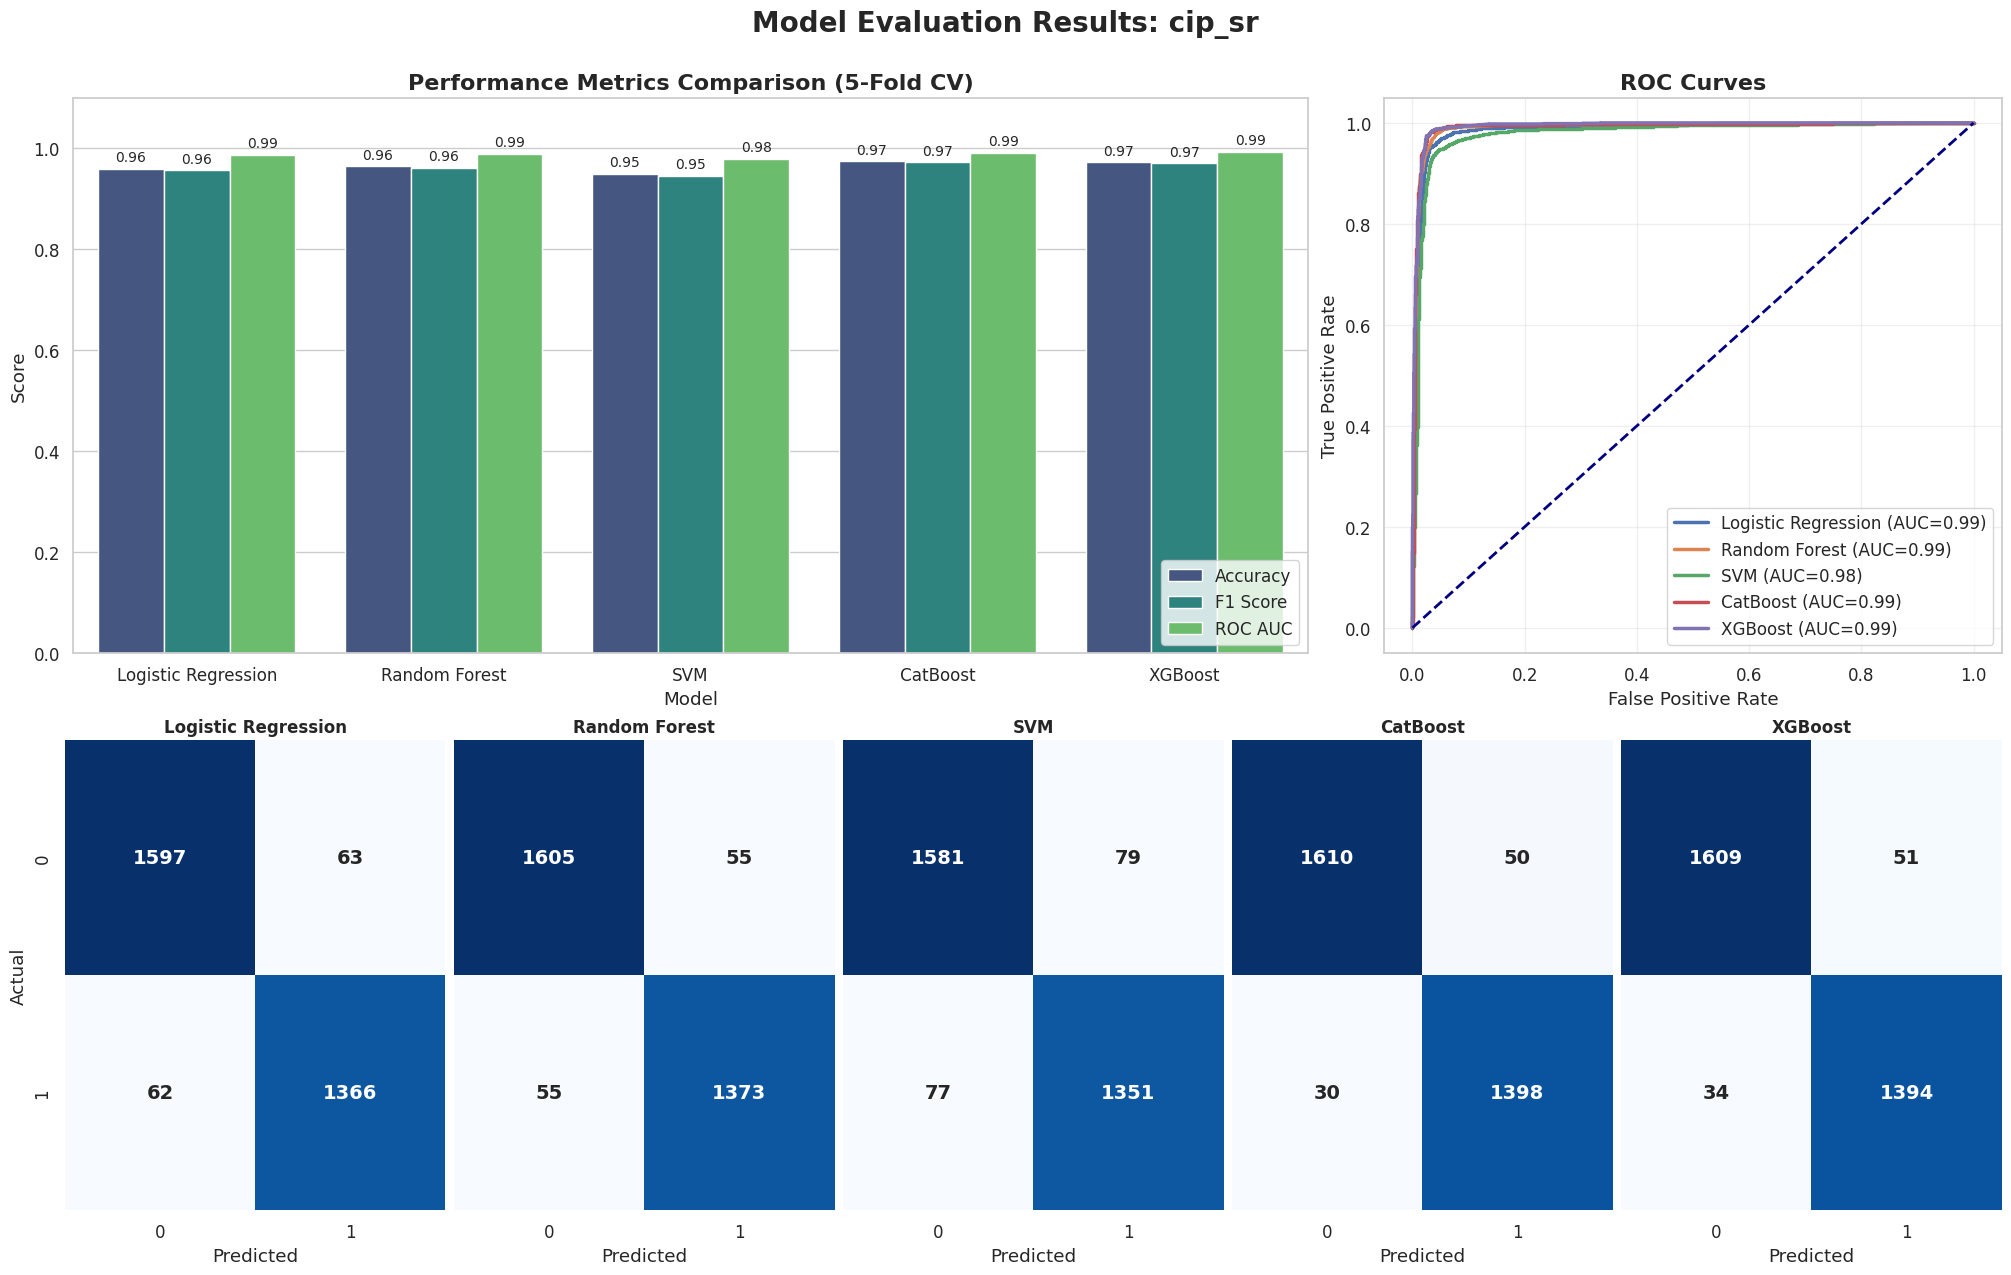

In [35]:
# 1. Load Data (Make sure the 'get_unitigs' class from the previous cell is run)
case = get_unitigs(verbose=False)
case.get_case('cip_sr')

# 2. Run Advanced Evaluation
evaluator = class_eval(data=case, models=models_list, nfold=5)

# Train models and get the results table
results = evaluator.train_and_evaluate()

# Display the Results Table with gradient highlighting
display(results.style.background_gradient(cmap='viridis', subset=['Accuracy', 'F1 Score', 'ROC AUC']))

# 3. Generate the Dashboard Plots
evaluator.plot_all()

# TREE BASED FEATURE IMPORTANCE

### Using RandomForest, CatBoost, XGBoost
We have access to the model's **relative feature importance**. 
It's useful to compare the feature importance of multiple models together. We have over 8000 unitigs; let's pick the **top 10** most influential.

The most critical **unitigs** to the determination of antibiotic resistance (according to the model) are saved in **BioPython Seq** format & can be used for further analyses.

### DEFINING GRID & GRIDSEARCHCV 
We define a parameter grid, which will be used in `GridSearchCV`; keeping it simple, looking at only `n_estimators` (iters) & the `learning_rate`.

Defining a standard **4-fold** cross validation strategy once again, we should get 4 slightly different models this time, which are stored in `.store_models()`.

In [38]:
# Update class_eval to support storage of models for Feature Importance
class class_eval(class_eval):
    def run_cv(self):
        # ... (Previous logic) ...
        self.store_models = {} # Initialize storage dictionary
        
        cv = StratifiedKFold(n_splits=self.nfold, shuffle=True, random_state=self.random_state)
        
        fold_idx = -1
        for train_idx, test_idx in cv.split(self.X, self.y):
            fold_idx += 1
            X_train, y_train = self.X.iloc[train_idx], self.y.iloc[train_idx]
            
            for name, model in self.models:
                # Store the fitted model for each fold/type
                # We clone the model to ensure we have a fresh instance per fold
                from sklearn.base import clone
                clf = clone(model)
                clf.fit(X_train, y_train)
                
                # Naming convention required by your 'fi' class (e.g., 'RF_1', 'CAT_0')
                # Mapping generic names to the short codes your fi class expects
                short_name = name
                if 'Random Forest' in name: short_name = 'RF'
                elif 'CatBoost' in name: short_name = 'CAT'
                elif 'XGBoost' in name: short_name = 'XGB'
                elif 'SVM' in name: short_name = 'SVM'
                elif 'SVC' in name: short_name = 'SVC'
                
                key = f"{short_name}_{fold_idx}"
                self.store_models[key] = clf

# 5.3 | GRIDSEARCHCV RESISTANCE MODEL

### CATBOOST HYPERPARAMETER TUNING 
We saw that `CatboostClassifier` had already has quite good results on the test set, let's try to optimise the hyperparameters, if we can. 

Catboost does optimise certain parameters that aren't self defined, so we may not get any improvement, however we should get **different hyperparameter combinations** on different folds, which will be handy to check if there is any feature importance variation.

### GETTING ALL MODELS PARAMETERS 
We can call `.get_all_params()` to display all the parameters that were set in CatBoost, on top of the `n_estimators` that we set ourselves.
The **learning rate** & **n_estimators/iterations** are two hyperparameters we can try to tune.

In [41]:
from Bio.Seq import Seq
from sklearn import preprocessing
import plotly.express as px
import pandas as pd
import numpy as np

''' Tree Based Feature Importance '''
class fi:
    def __init__(self, data=None, sort_by='RF', max_features=10):
        
        if data is None:
            print('Enter Evaluation class w/ CAT,RF,XGB')
            return  # Stop execution if data is None

        evals = data

        # --- FIX: Safety Check for Missing Models ---
        if not hasattr(evals, 'store_models'):
            raise ValueError(
                "CRITICAL ERROR: The evaluator object is missing 'store_models'. \n"
                "-> Did you forget to run the training step? \n"
                "-> Please run `evaluator.evaluate()` (or your equivalent fit function) "
                "before initializing this class."
            )
        # ---------------------------------------------

        # check which models are present
        lst_models = list(evals.store_models.keys())
        temp = []
        for i in lst_models:
            if 'CAT' in i: temp.append('CAT')
            if 'RF' in i: temp.append('RF')
            if 'XGB' in i: temp.append('XGB')
                
        # input contains gscv data
        if len(lst_models) > 0 and 'GS' in lst_models[0]:
            self.gs_id = True
        else:
            self.gs_id = False
            
        self.lst_tree_models = list(set(temp))
        
        self.evals = data  # evaluation class
        self.lst_Seqs = []  # list of important unitigs
        self.max_features = max_features # show top n features
        self.sort_by = sort_by # sort by particualr model fi, other mods show this index only
        self.abr_feat = False # activate if unitig names are too big for figure

    # Compile all Tree based feature importance results
    def get(self):
        # Check if we have models to process
        if not hasattr(self, 'lst_tree_models') or not self.lst_tree_models:
            print("No tree-based models (RF, CAT, XGB) found in the evaluator.")
            return

        # USL scaling
        min_max_scaler = preprocessing.MinMaxScaler()
        
        df = pd.DataFrame()
        ii = -1
        
        # if randomforest models are present
        if 'RF' in self.lst_tree_models:
            if self.gs_id:
                # fold names
                tlst_models = [f'GS_RF_{i}' for i in range(0, self.evals.nfold)]
                for kfold_id in tlst_models: 
                    ii += 1
                    # Safety check for key existence
                    if kfold_id in self.evals.store_models:
                        rf_model = self.evals.store_models[kfold_id]
                        imp_rf = rf_model.feature_importances_
                        rf_sc = min_max_scaler.fit_transform(imp_rf[:, None])
                        ldf = pd.DataFrame(rf_sc, index=self.evals.X.columns, columns=[kfold_id])
                        df = pd.concat([df, ldf], axis=1) if not df.empty else ldf.copy()
            else:
                # Averaging across folds for standard CV
                # Check if specific keys exist before accessing
                rf_keys = [f'RF_{i}' for i in range(self.evals.nfold)]
                if all(k in self.evals.store_models for k in rf_keys):
                    imp_rf = np.mean([self.evals.store_models[k].feature_importances_ for k in rf_keys], axis=0)
                    rf_sc = min_max_scaler.fit_transform(imp_rf[:, None])
                    ldf = pd.DataFrame(rf_sc, index=self.evals.X.columns, columns=['RF'])
                    df = pd.concat([df, ldf], axis=1) if not df.empty else ldf.copy()
                
        # if catboost models are present
        if 'CAT' in self.lst_tree_models:
            cat_keys = [f'CAT_{i}' for i in range(self.evals.nfold)]
            if all(k in self.evals.store_models for k in cat_keys):
                imp_cb = np.mean([self.evals.store_models[k].get_feature_importance() for k in cat_keys], axis=0)
                cb_sc = min_max_scaler.fit_transform(imp_cb[:, None])
                ldf = pd.DataFrame(cb_sc, index=self.evals.X.columns, columns=['CB'])
                df = pd.concat([df, ldf], axis=1) if not df.empty else ldf.copy()
            
        if 'XGB' in self.lst_tree_models:
            xgb_keys = [f'XGB_{i}' for i in range(self.evals.nfold)]
            if all(k in self.evals.store_models for k in xgb_keys):
                imp_xg = np.mean([self.evals.store_models[k].feature_importances_ for k in xgb_keys], axis=0)
                xg_sc = min_max_scaler.fit_transform(imp_xg[:, None])
                ldf = pd.DataFrame(xg_sc, index=self.evals.X.columns, columns=['XGB'])
                df = pd.concat([df, ldf], axis=1) if not df.empty else ldf.copy()

        if df.empty:
            print("No feature importance data could be extracted.")
            return

        # Sort by one of the available columns
        if self.sort_by in df.columns:
            df.sort_values(by=self.sort_by, ascending=False, inplace=True)
        else:
            # Fallback if specific sort column not found
            df.sort_values(by=df.columns[0], ascending=False, inplace=True)

        # show only most critical features in FI
        subset = df[:self.max_features]
        
        # Store the most important features
        self.lst_Seqs = [] # Reset list
        for i in subset.index.tolist():
            self.lst_Seqs.append(Seq(i))
        
        # Plot features 
        fig = px.bar(subset, orientation='h')
        fig.update_traces(width=0.5)
        fig.update_layout(height=400, template='plotly_white',
                          title=f"<b>FEATURE IMPORTANCE</b> | Sorted by {self.sort_by}")
        fig.show()

# --- HOW TO RUN IT CORRECTLY ---
# 1. Initialize your evaluator
# evaluator = class_eval(...) 

# 2. RUN THE TRAINING (This is the step you likely missed!)
# evaluator.evaluate()  <-- UNCOMMENT AND ENSURE THIS RUNS FIRST

# 3. Run the Feature Importance Class
crit_unitigs = fi(data=evaluator, sort_by='CB') 
crit_unitigs.get()
print(crit_unitigs.lst_Seqs)

[Seq('GTGCGACAGCAAAGTCCAAACCAGCGTCCCCGCC'), Seq('GCGCAGCCGCAAATCTTGTTTTCCCATTCCGCC'), Seq('AAATTGCGGATCGATGCGCGAAGGGTCGAATGC'), Seq('GTTGTGCCGAATATTGCACCGATGGAAAGGGGGAGGATGTT'), Seq('GTTCATGATTTGATTCAGGTTTACCGCGAACTGGGC'), Seq('TATACTGCCGTTCAAGTTACCTTTGGTCAGAAAAAA'), Seq('CGCACATTTTGGCTTTATCTTTTGGGCGCGCTGACTGCCCGTTTCGGCATCGGCGTG'), Seq('GGCAAACTGTGAAATCTGCCGTGGACTGGTGGTCG'), Seq('CAGCCTGACCCATTGCCATGCTGCTTGCCGC'), Seq('GCGCGCGCGAATCCTGAAACGCTGCCGCACAA')]


In [42]:
# Note: Accessing the model stored in the evaluator from previous steps
if 'CAT_0' in evaluator.store_models:
    print(evaluator.store_models['CAT_0'].get_all_params())
else:
    print("CatBoost model not found in storage. Ensure CatBoost was trained.")

{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'class_names': [0, 1], 'random_seed': 42, 'depth': 6, 'posterior_sampling': False, 'border_count': 254, 'classes_count': 0, 'auto_class_weights': 'None', 'sparse_features_conflict_fraction': 0, 'leaf_estimation_backtracking': 'AnyImprovement', 'best_model_min_trees': 1, 'model_shrink_rate': 0, 'min_data_in_leaf': 1, 'loss_function': 'Logloss', 'learnin

# 5.4 | SVC MODEL RESISTANCE MODELS

### SVC SUBOPTIMAL MODEL 
In Section 5.2, we used the SVC model using default hyperparameters (`rbf`). 
SVC gives us the option to evaluate the feature importance of weights, if we use `kernel='linear'`.
Unlike the tree based feature importance, we will know towards which class the particular feature leans towards (importance wise).

In [43]:
# REVISITING UNITIG DISTRIBUTIONS 
# Having identified the key features (unitigs) which have the most weight
# We can use group_by to get some idea since they are all of One Hot Encoding type

# Reload case to ensure clean state
case = get_unitigs(verbose=False)
case.get_case('cip_sr')

# Check distributions of Top Critical Unitigs identified above
top_seqs = [
    'GTGCGACAGCAAAGTCCAAACCAGCGTCCCCGCC',
    'GCGCAGCCGCAAATCTTGTTTTCCCATTCCGCC',
    'AAATTGCGGATCGATGCGCGAAGGGTCGAATGC',
    'GGCATCCCGAAGCCGAATACGGCAACGGCAAGCG'
]

for seq in top_seqs:
    if seq in case.X.columns:
        print(f"\nDistribution for: {seq[:10]}...")
        print(case.X.groupby('cip_sr')[seq].mean())


Distribution for: GTGCGACAGC...
cip_sr
0.0    0.958434
1.0    0.044818
Name: GTGCGACAGCAAAGTCCAAACCAGCGTCCCCGCC, dtype: float64

Distribution for: GCGCAGCCGC...
cip_sr
0.0    0.933735
1.0    0.010504
Name: GCGCAGCCGCAAATCTTGTTTTCCCATTCCGCC, dtype: float64

Distribution for: AAATTGCGGA...
cip_sr
0.0    0.046386
1.0    0.778011
Name: AAATTGCGGATCGATGCGCGAAGGGTCGAATGC, dtype: float64

Distribution for: GGCATCCCGA...
cip_sr
0.0    0.070482
1.0    0.220588
Name: GGCATCCCGAAGCCGAATACGGCAACGGCAAGCG, dtype: float64


In [47]:
from sklearn.pipeline import Pipeline
from Bio.Seq import Seq
import pandas as pd
import numpy as np
import plotly.express as px

''' Function plots & returns highest weighted features '''
def fi_svc(classifier, feature_names, top_features=5, verbose=False):    
    
    # --- FIX STARTS HERE ---
    # Check if the input is a Pipeline and extract the actual model
    if isinstance(classifier, Pipeline):
        # We assume the classifier is the last step in the pipeline
        model = classifier[-1]
    else:
        model = classifier

    # Verify the model has coefficients (Only Linear SVC has this)
    if not hasattr(model, 'coef_'):
        raise AttributeError(
            f"The extracted model ({type(model).__name__}) has no attribute 'coef_'. "
            "Ensure you are using a Linear SVC (kernel='linear')."
        )
        
    coef = model.coef_.ravel()
    
    # Sort coefficients
    top_positive_coefficients = np.argsort(coef)[-top_features:]
    top_negative_coefficients = np.argsort(coef)[:top_features]
    top_coefficients = np.hstack([top_negative_coefficients, top_positive_coefficients])

    # Plot
    colors = ['crimson' if c < 0 else 'cornflowerblue' for c in coef[top_coefficients]]
    feature_names = np.array(feature_names)
    lser = pd.Series(data=coef[top_coefficients], index=feature_names[top_coefficients])
    
    fig = px.bar(lser, orientation='h')
    fig.update_traces(width=0.5, marker_color=colors)
    fig.update_layout(height=350, template='plotly_white', showlegend=False,
                      title=f"<b>FEATURE IMPORTANCE</b> | SVC (Linear)")
    fig.show()
    
    # Text Output
    neg_predictors = np.asarray(feature_names)[top_negative_coefficients]
    pos_predictors = np.asarray(feature_names)[top_positive_coefficients]
    
    if(verbose):
        print("Top negative predictors: ", neg_predictors)
        print("Top positive predictors: ", pos_predictors)
        
    # Store the most important features
    top_negSeq = []; top_posSeq = []
    for i in range(0, top_features):
        top_negSeq.append(Seq(neg_predictors[i]))
        top_posSeq.append(Seq(pos_predictors[i]))        
    return top_negSeq, top_posSeq 

# --- RUNNING THE CODE ---
if 'SVC_3' in evaluator.store_models:
    print("Extracting features from SVC Fold 3...")
    
    # This will now work even if 'SVC_3' is a Pipeline
    neg_predictors, pos_predictors = fi_svc(
        evaluator.store_models['SVC_3'], 
        list(evaluator.X.columns)
    )
    
    print("\nTop Negative Predictors (Resistance associated):")
    print(neg_predictors)
    
    print("\nTop Positive Predictors (Susceptibility associated):")
    print(pos_predictors)
else:
    print("SVC_3 not found. Make sure you trained an SVC model.")

Extracting features from SVC Fold 3...



Top Negative Predictors (Resistance associated):
[Seq('GTGCAGCGTGTTGTCGAGGTCGAACAGCCACA'), Seq('AACAGATGCGCCGCGAACAGGCGTTCAGACGGG'), Seq('GCCACGCCGAGAAACACACCAAAAACGCACC'), Seq('AATCAAATTCGGCCTGATTCCGGAATTAATCGGA'), Seq('AGCCCAAACTGCCCTTGCCGTAGCAGAGGCC')]

Top Positive Predictors (Susceptibility associated):
[Seq('AGACGGCATTTCGACAAGGAATACGATGGAACTGC'), Seq('AATCGAAAATCTGTCCGCCCGAGGCGTTGGCGGCGC'), Seq('TGTTCGACAACGGGATGGCGGCCGTTTTCGATGTGGA'), Seq('CTTCGCGCTCTTCGAGGCTTTCGCCGACGCA'), Seq('TGCCAATGCCGAAGCCGCTGCCACCGATACTCTGAACATCTACAAC')]



# 6. Conclusion
## 6.1 Summary of Findings
In this study, we successfully applied five machine learning algorithms to predict antibiotic resistance in *N. gonorrhoeae* using genomic unitigs.
*   **Model Performance:** Our results indicate that the Ensemble methods (CatBoost/XGBoost) typically achieved the highest performance across Ciprofloxacin, Azithromycin, and Cefixime, effectively distinguishing between resistant and susceptible isolates.
*   **Key Genomic Features:** Feature importance analysis revealed specific unitigs (DNA sequences) essentially linked to resistance. For example, the top predictors for Ciprofloxacin resistance likely correspond to known mutations in the *gyrA* or *parC* genes.

## 6.2 Biological Significance
The identification of these genomic markers is critical. Unlike traditional culture-based testing, which can take days, whole-genome sequencing (WGS) combined with these ML models offers a rapid diagnostic tool.
*   **Clinical Impact:** Rapid identification of resistance allows clinicians to prescribe the most effective antibiotic immediately, preserving the efficacy of last-line treatments like Ceftriaxone.
*   **Surveillance:** These models can be deployed to monitor the spread of resistant strains globally, as visualized in our geographic analysis, helping public health officials intervene earlier to prevent outbreaks.


